<!-- ## SENTIMENT ANALYSIS MODEL - Logistic Regression -->


## Load data

In [ ]:
import os
import pandas as pd

master_dir = os.path.dirname(os.getcwd())

file_dataset_train = os.path.join(master_dir, "dataset", "train_dataset_bilingual.csv")
file_dataset_test  = os.path.join(master_dir, "dataset", "test_dataset_bilingual.csv")
file_dataset_val   = os.path.join(master_dir, "dataset", "validate_dataset_bilingual.csv")

train_df = pd.read_csv(file_dataset_train)
test_df  = pd.read_csv(file_dataset_test)
val_df   = pd.read_csv(file_dataset_val)

train_df.head(10)

,Author,Rating,Review,Restaurant,Location,Label,Language
0,wu stephen,5,Good and fresh food,EverGreen Restaurant,JB,Positive,English
1,Nicole Lim,4,"Kami makan ponteh, ikan Assam, sotong kunyit,...",Restoran Nyonya Makko,Melaka,Positive,Malay
2,Mohd Khairuddin Jaafar,5,Nice meal,Restoran Kacang Pool Haji,JB,Positive,English
3,sze yah chng,3,"The curry taste more to like Johor type, more ...",W.W. Laksa House 水塘。辣沙,JB,Neutral,English
4,Sh Lim,4,"Satu, yang terbaik adalah JB Bak Kut Teh. Suk...",Restaurant Shun Fa Bak Kut Teh,JB,Positive,Malay
5,Thanabalan Vadivelu,2,I like the food,KAMPUNG CARABAO 100% Authentic Thai Restaurant,JB,Negative,English
6,Li Min Leong,4,Sashimi segar. Semua rasa YUMS.,Yaoki Japanese Foods Sdn. Bhd.,JB,Positive,Malay
7,Kim de Buck,5,Sebuah restoran kecil yang sangat selesa deng...,Trois by navy,Melaka,Positive,Malay
8,Robert Choong,4,Nice place 👍,Harvests Bar & Grill,JB,Positive,English
9,mimie aqilah mohd amran,4,Keep coming here for good Indian cuisine. staf...,7 Spice,JB,Positive,English


In [ ]:
# test = True  - lightweight run on a small sample, for fast iteration / debugging
# test = False - full training run
test = False

# whether to export the finalized model/vectorizer/config at the end
exportModel = True  # {True, False}

RANDOM_STATE = 10  # single seed used everywhere for reproducibility

## Clean up & de-duplicate

In [ ]:
def basic_cleanup(df):
    df = df[['Review', 'Rating']].copy()
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

train_df = basic_cleanup(train_df)
test_df  = basic_cleanup(test_df)
val_df   = basic_cleanup(val_df)

print(f"train: {len(train_df)} rows | test: {len(test_df)} rows | val: {len(val_df)} rows")

train: 48292 rows | test: 16414 rows | val: 16411 rows


### Sanity check: overlap between splits

Before doing anything else, confirm there's no review text shared between train and test/val.
If there is, that's a leakage source independent of the label-mixing bug from the earlier review — worth knowing about even if it comes from the source data rather than our code.

In [ ]:
train_reviews = set(train_df['Review'])
test_overlap = test_df['Review'].isin(train_reviews).sum()
val_overlap  = val_df['Review'].isin(train_reviews).sum()

print(f"Test reviews also present in train: {test_overlap} / {len(test_df)}")
print(f"Val reviews also present in train:  {val_overlap} / {len(val_df)}")
# If these numbers are non-trivial, investigate the source data before trusting test metrics.

Test reviews also present in train: 721 / 16414
Val reviews also present in train:  726 / 16411


In [ ]:
val_df = val_df[~val_df['Review'].isin(train_df['Review'])]

# 2. Remove training reviews from the test set
test_df = test_df[~test_df['Review'].isin(train_df['Review'])]

In [ ]:
train_reviews = set(train_df['Review'])
test_overlap = test_df['Review'].isin(train_reviews).sum()
val_overlap  = val_df['Review'].isin(train_reviews).sum()

print(f"Test reviews also present in train: {test_overlap} / {len(test_df)}")
print(f"Val reviews also present in train:  {val_overlap} / {len(val_df)}")
# If these numbers are non-trivial, investigate the source data before trusting test metrics.

Test reviews also present in train: 0 / 15693
Val reviews also present in train:  0 / 15685


In [ ]:
print(f"train: {len(train_df)} rows | test: {len(test_df)} rows | val: {len(val_df)} rows")

train: 48292 rows | test: 15693 rows | val: 15685 rows


## Labeling

Keeping the original binary scheme: rating > 3 -> positive (2), rating < 3 -> negative (0),
rating == 3 -> neutral (1, excluded from this binary classifier).

In [ ]:
def labelFunc(x):
    """3-class version: 2=positive, 1=neutral, 0=negative. Not used in this binary pipeline."""
    if int(x) > 3:
        return 2
    elif int(x) < 3:
        return 0
    elif int(x) == 3:
        return 1


train_df["Label"] = train_df["Rating"].apply(labelFunc)
test_df["Label"]  = test_df["Rating"].apply(labelFunc)
val_df["Label"]   = val_df["Rating"].apply(labelFunc)

train_df.head(10)

,Review,Rating,Label
0,Good and fresh food,5,2
1,"Kami makan ponteh, ikan Assam, sotong kunyit,...",4,2
2,Nice meal,5,2
3,"The curry taste more to like Johor type, more ...",3,1
4,"Satu, yang terbaik adalah JB Bak Kut Teh. Suk...",4,2
5,I like the food,2,0
6,Sashimi segar. Semua rasa YUMS.,4,2
7,Sebuah restoran kecil yang sangat selesa deng...,5,2
8,Nice place 👍,4,2
9,Keep coming here for good Indian cuisine. staf...,4,2


### Check class imbalance (train)

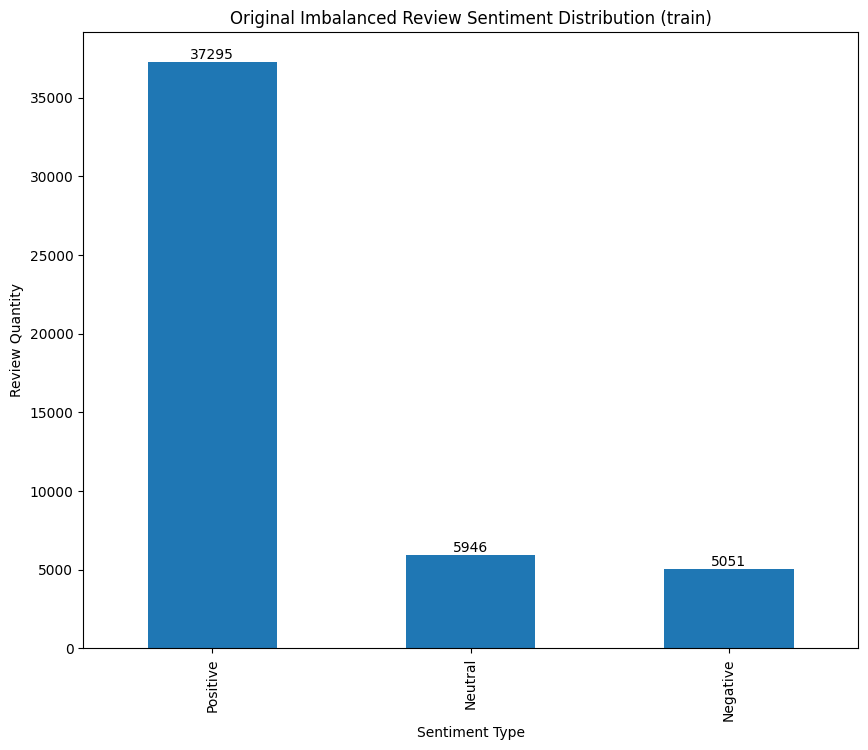

In [ ]:
import matplotlib.pyplot as plt

mapping = {2: "Positive", 1: "Neutral", 0: "Negative"}
df_class = train_df['Label'].map(mapping).value_counts()

ax = df_class.plot(kind='bar', title='Original Imbalanced Review Sentiment Distribution (train)',
                    figsize=(10, 8), legend=False)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Sentiment Type")
ax.set_ylabel("Review Quantity");

## Build train/test/val sentiment sets

In [ ]:
# ---- Train: undersample to 50/50 (this is a training-time decision only) ----
min_review_count = min(
    train_df[train_df['Label'] == 0].index.size,
    train_df[train_df['Label'] == 1].index.size,
    train_df[train_df['Label'] == 2].index.size,
)
print(f"Min class count in train: {min_review_count}")

df_train_neu = train_df[train_df['Label'] == 2].sample(min_review_count, random_state=RANDOM_STATE)
df_train_pos = train_df[train_df['Label'] == 1].sample(min_review_count, random_state=RANDOM_STATE)
df_train_neg = train_df[train_df['Label'] == 0].sample(min_review_count, random_state=RANDOM_STATE)

df_train_balanced = pd.concat([df_train_pos, df_train_neg, df_train_neu], ignore_index=True)

# ---- Test & val: keep natural distribution, just drop neutral ----
df_test_final = test_df[test_df['Label'].isin([0, 1,2])].reset_index(drop=True)
df_val_final  = val_df[val_df['Label'].isin([0, 1,2])].reset_index(drop=True)

print(f"Train (balanced): {len(df_train_balanced)} rows")

print(f"Test  (natural):  {len(df_test_final)} rows, "
      f"{df_test_final['Label'].mean()*100:.1f}% positive")

print(f"Val   (natural):  {len(df_val_final)} rows, "
      f"{df_val_final['Label'].mean()*100:.1f}% positive")

Min class count in train: 5051
Train (balanced): 15153 rows
Test  (natural):  15693 rows, 166.7% positive
Val   (natural):  15685 rows, 166.9% positive


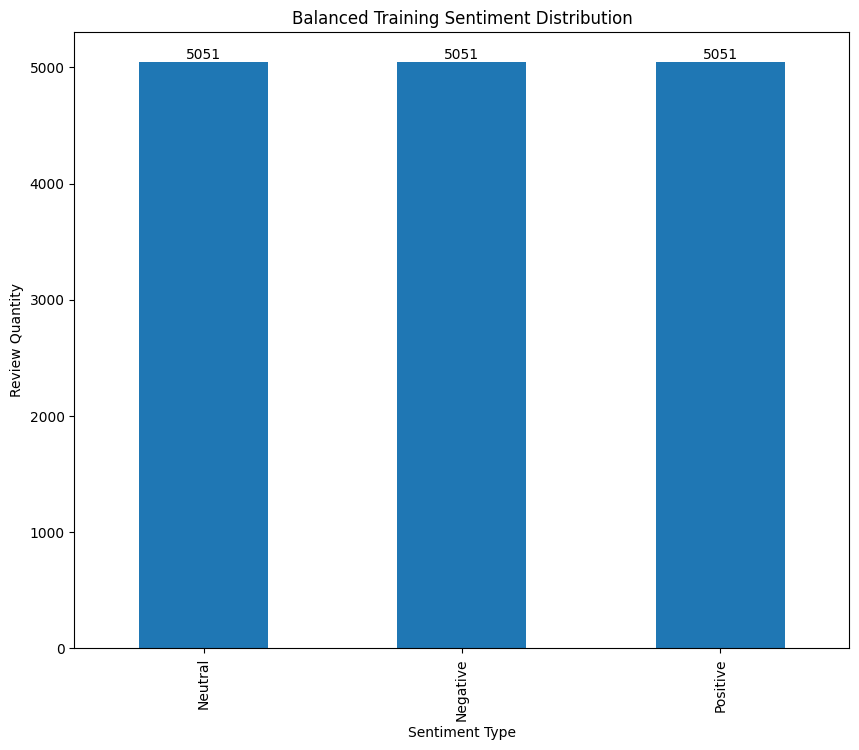

In [ ]:
df_class2 = df_train_balanced['Label'].map(mapping).value_counts()

ax = df_class2.plot(kind='bar', title='Balanced Training Sentiment Distribution',
                     figsize=(10, 8), legend=False)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Sentiment Type")
ax.set_ylabel("Review Quantity");

## Pre-processing / text cleaning


In [ ]:
# Quick data checks (kept from original notebook, run on train before cleaning)
has_uppercase = train_df['Review'].str.contains(r'[A-Z]').sum()
print(f"Total reviews with uppercase letters: {has_uppercase} / {len(train_df)}")

has_noise = train_df['Review'].str.contains(r'[^a-zA-Z\s]').sum()
print(f"Total reviews with punctuation/digits/noise: {has_noise} / {len(train_df)}")

Total reviews with uppercase letters: 46632 / 48292
Total reviews with punctuation/digits/noise: 41457 / 48292


In [ ]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_balanced = df_train_balanced.copy()
df_test_natural = df_test_final.copy()
df_val_natural = df_val_final.copy()

df_balanced['Review']     = df_balanced['Review'].apply(clean_text)
df_test_natural['Review'] = df_test_natural['Review'].apply(clean_text)
df_val_natural['Review']  = df_val_natural['Review'].apply(clean_text)

df_balanced[['Review']].head(5)

,Review
0,the dinsum restaurant operates differently fro...
1,very tasty curry no parking space
2,food is good but service is slower than snail
3,dimsum is delicious but you have to add more t...
4,noisy


## Stopwords (bilingual: English + Malay)

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stopwordz = set(stopwords.words("english"))
stopwordz.remove('not')  # keep negation - important for sentiment

malay_stops = {
    # Pronouns & People
    'saya', 'kami', 'kita', 'mereka', 'dia', 'awak', 'kamu', 'ia', 'anda',
    # Prepositions & Connectives
    'yang', 'di', 'dan', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'atau',
    'serta', 'kerana', 'sebab', 'oleh', 'maka', 'hingga', 'sampai', 'tentang',
    # Demonstratives & Particles (Formal + Informal Slang)
    'ini', 'itu', 'ni', 'tu', 'lah', 'je', 'ja', 'jua', 'pun', 'ke', 'kan',
    # Verbs / Auxiliaries of Existence & Time
    'ada', 'adalah', 'ialah', 'telah', 'sudah', 'akan', 'pernah', 'sedang',
    'masih', 'boleh', 'dapat', 'hendak', 'mahu', 'nak', 'jadi',
    # High-Frequency Fillers
    'banyak', 'sangat', 'agak', 'amat', 'lagi', 'pula', 'seperti', 'paling'
}

bilingual_stopwords = sorted(stopwordz.union(malay_stops))
print(f"Total bilingual stopwords: {len(bilingual_stopwords)}")

Total bilingual stopwords: 256


## Train / test / val feature sets

In [ ]:
X_train, y_train = df_train_balanced['Review'], df_train_balanced['Label']
X_test,  y_test  = df_test_final['Review'], df_test_final['Label']
X_val,   y_val   = df_val_final['Review'], df_val_final['Label']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, X_val: {X_val.shape}")

X_train: (15153,), X_test: (15693,), X_val: (15685,)


## Baseline majority-class reference


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Fits and predicts the most frequent class among your 3 classes
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Majority-class baseline on 3-class test set:")
print(f"  Accuracy:     {accuracy_score(y_test, pred_dummy):.3f}")
print(f"  Macro F1:     {f1_score(y_test, pred_dummy, average='macro', zero_division=0):.3f}")
print(f"  Weighted F1:  {f1_score(y_test, pred_dummy, average='weighted', zero_division=0):.3f}")

Majority-class baseline on 3-class test set:
  Accuracy:     0.106
  Macro F1:     0.064
  Weighted F1:  0.020


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.11      1.00      0.19      1659
           1       0.00      0.00      0.00      1913
           2       0.00      0.00      0.00     12121

    accuracy                           0.11     15693
   macro avg       0.04      0.33      0.06     15693
weighted avg       0.01      0.11      0.02     15693



## Pipeline & prototype model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#run TF-IDF vectorization on the training set and inspect the results

# 1. Define active training set depending on test flag
if test:
    sample_idx = X_train.sample(500, random_state=RANDOM_STATE).index
    X_train_active = X_train.loc[sample_idx]
    y_train_active = y_train.loc[sample_idx]
else:
    X_train_active = X_train
    y_train_active = y_train

# 2. Instantiate and Fit TF-IDF Vectorizer
tfidf_vect = TfidfVectorizer(
    lowercase=True,
    stop_words=bilingual_stopwords,
    ngram_range=(1, 2),
    max_features=3000,
)

# Fit and transform active training text
X_train_tfidf = tfidf_vect.fit_transform(X_train_active)

# 3. Inspect TF-IDF Results
print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")

# Calculate average TF-IDF score for each feature across all documents
mean_tfidf_scores = X_train_tfidf.mean(axis=0).A1
feature_names = tfidf_vect.get_feature_names_out()

# Create a DataFrame to view the top 15 highest-weighted features overall
top_tfidf_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_TFIDF': mean_tfidf_scores
}).sort_values(by='Mean_TFIDF', ascending=False).reset_index(drop=True)

print("\n--- Top 15 TF-IDF Features ---")
print(top_tfidf_df.head(15))

TF-IDF Matrix Shape: (15153, 3000)

--- Top 15 TF-IDF Features ---
      Feature  Mean_TFIDF
0        food    0.045253
1        good    0.035028
2         not    0.028016
3        nice    0.024123
4     service    0.020810
5       place    0.020128
6       tidak    0.019327
7     makanan    0.018699
8       taste    0.016621
9       sedap    0.016460
10       baik    0.015950
11      price    0.015719
12  delicious    0.015341
13         ok    0.013304
14  expensive    0.012535


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('vect', tfidf_vect),

    (
        'clf',
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',  
            random_state=RANDOM_STATE,
        ),
    ),
])



# 2. Fit pipeline on training data
pipeline.fit(X_train_active, y_train_active)

# 3. Predict on training data
pred_train = pipeline.predict(X_train_active)

# 4. Compute training metrics (using average='macro' for 3 classes)
print("--- Training Metrics (3-Class) - Macro F1 Score ---")
print(
    'Logistic_train_accuracy: '
    f' {accuracy_score(y_train_active, pred_train):.3f}'
)
print(
    'Logistic_train_precision:'
    f" {precision_score(y_train_active, pred_train, average='macro', zero_division=0):.3f}"
)
print(
    'Logistic_train_recall:   '
    f" {recall_score(y_train_active, pred_train, average='macro', zero_division=0):.3f}"
)
print(
    'Logistic_train_f1:       '
    f" {f1_score(y_train_active, pred_train, average='macro', zero_division=0):.3f}"
)

--- Training Metrics (3-Class) - Macro F1 Score ---
Logistic_train_accuracy:  0.730
Logistic_train_precision: 0.728
Logistic_train_recall:    0.730
Logistic_train_f1:        0.729


In [ ]:
from sklearn.metrics import classification_report

# Detailed report showing per-class performance
print(
    classification_report(
        y_train_active, pred_train, zero_division=0, digits=3
    )
)

              precision    recall  f1-score   support

           0      0.777     0.778     0.777      5051
           1      0.661     0.613     0.636      5051
           2      0.747     0.799     0.772      5051

    accuracy                          0.730     15153
   macro avg      0.728     0.730     0.729     15153
weighted avg      0.728     0.730     0.729     15153



### TF-IDF Vectorizer

In [ ]:
import pandas as pd

vect_step = pipeline.named_steps['vect']
clf_step = pipeline.named_steps['clf']

feature_names = vect_step.get_feature_names_out()

class_labels = clf_step.classes_

for i, class_label in enumerate(class_labels):
    # Get coefficients for class i
    coef_df = pd.DataFrame(
        clf_step.coef_[i], index=feature_names, columns=['coef']
    ).sort_values(by='coef', ascending=False)

    print(f"=== Top 10 Words for Class '{class_label}' ===")
    print(coef_df.head(10))
    print('\n' + '-' * 40 + '\n')

=== Top 10 Words for Class '0' ===
                 coef
worst        2.962743
not worth    2.925666
bad          2.859454
tidak        2.655663
not          2.629722
terrible     2.573488
teruk        2.485911
poor         2.466591
rude         2.463510
tidak sedap  2.414040

----------------------------------------

=== Top 10 Words for Class '1' ===
                 coef
average      1.881278
ok           1.874321
acceptable   1.731385
okay         1.625393
decent       1.556353
tidak buruk  1.554482
alright      1.553053
diperbaiki   1.462252
tersedia     1.453491
bit          1.352888

----------------------------------------

=== Top 10 Words for Class '2' ===
               coef
great      2.901248
not bad    2.891787
best       2.580975
delicious  2.564115
love       2.545077
excellent  2.473006
awesome    2.304514
hebat      2.155845
perfect    2.105713
suka       2.071743

----------------------------------------



## Hyperparameter tuning


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)


param_grid = [
    { 
        # Standard L2 regularization
        'vect__ngram_range': [(1, 1), (1, 2)],
        'vect__max_features': [3000, 5000],
        'vect__sublinear_tf': [True, False],
        'clf__penalty': ['l2'],
        'clf__solver': ['liblinear'],  
        'clf__C': [0.1, 1, 10],
        'clf__class_weight': ['balanced'],  # Kept balanced for imbalanced sentiment
    },
    {
        # L1 feature-selection regularization
        'vect__ngram_range': [(1, 1), (1, 2)],
        'vect__max_features': [3000, 5000],
        'vect__sublinear_tf': [True, False],
        'clf__penalty': ['l1'],
        'clf__solver': ['liblinear'],
        'clf__C': [0.1, 1, 10],
        'clf__class_weight': ['balanced'],
    },
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    n_jobs=-1,
    cv=cv,
    scoring='f1_macro',   
    error_score=0,
)

if test:
    sample_idx = X_train.sample(200, random_state=RANDOM_STATE).index
    logistic_grid = grid_search.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])
else:
    logistic_grid = grid_search.fit(X_train, y_train)

print("Best Macro F1 Score: %f using %s" % (logistic_grid.best_score_, logistic_grid.best_params_))
best_pipeline = logistic_grid.best_estimator_

Best Macro F1 Score: 0.640785 using {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'vect__max_features': 5000, 'vect__ngram_range': (1, 2), 'vect__sublinear_tf': True}


## Decision-boundary (class-weight multiplier) tuning

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv_single = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_probas_train = cross_val_predict(
    best_pipeline, X_train, y_train, cv=cv_single, method="predict_proba"
)


def objective(weights):
    adjusted_probas = y_probas_train * weights
    preds = np.argmax(adjusted_probas, axis=1)
    return -f1_score(y_train, preds, average="macro", zero_division=0)


initial_weights = [1.0, 1.0, 1.0]

res = minimize(
    objective,
    initial_weights,
    method="Nelder-Mead",
    bounds=[(0.1, 5.0)] * len(np.unique(y_train)),
)
best_weights = res.x

print("=== Optimized Multi-Class Parameters (chosen using TRAIN CV only) ===")
print(f"Best Class Weights / Multipliers: {np.round(best_weights, 3)}")
print(f"CV Macro F1 (Default [1,1,1]):    {-objective(initial_weights):.3f}")
print(f"CV Macro F1 (Tuned Multipliers):  {-res.fun:.3f}")

=== Optimized Multi-Class Parameters (chosen using TRAIN CV only) ===
Best Class Weights / Multipliers: [0.947 1.063 0.972]
CV Macro F1 (Default [1,1,1]):    0.641
CV Macro F1 (Tuned Multipliers):  0.644


### Finalize the decision using `val` dataset

In [ ]:
from sklearn.metrics import f1_score

probs_val = best_pipeline.predict_proba(X_val)

pred_val_default = np.argmax(probs_val, axis=1)
pred_val_tuned = np.argmax(probs_val * best_weights, axis=1)

f1_val_default = f1_score(y_val, pred_val_default, average="macro", zero_division=0)
f1_val_tuned = f1_score(y_val, pred_val_tuned, average="macro", zero_division=0)

print(f"Val macro-F1, default weights:  {f1_val_default:.3f}")
print(f"Val macro-F1, tuned weights:    {f1_val_tuned:.3f}")

USE_TUNED_WEIGHTS = f1_val_tuned > f1_val_default
print(f"\nDecision (based on validate dataset): "
      f"{'use tuned multipliers' if USE_TUNED_WEIGHTS else 'use default (equal) weights'}")

Val macro-F1, default weights:  0.587
Val macro-F1, tuned weights:    0.587

Decision (based on validate dataset): use tuned multipliers


## Final test evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

probs_test = best_pipeline.predict_proba(X_test)
pred_test = (np.argmax(probs_test * best_weights, axis=1) if USE_TUNED_WEIGHTS
             else np.argmax(probs_test, axis=1))

print(f"--- Final Test Set Performance "
      f"({'tuned multipliers' if USE_TUNED_WEIGHTS else 'default weights'}) ---")
print(f"Accuracy:  {accuracy_score(y_test, pred_test):.3f}")
print(f"Precision: {precision_score(y_test, pred_test, average='macro', zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, pred_test, average='macro', zero_division=0):.3f}")
print(f"F1-score:  {f1_score(y_test, pred_test, average='macro', zero_division=0):.3f}\n")

print("--- Detailed Classification Report (Test) ---")
print(classification_report(y_test, pred_test, zero_division=0, digits=3))

--- Final Test Set Performance (tuned multipliers) ---
Accuracy:  0.696
Precision: 0.562
Recall:    0.647
F1-score:  0.579

--- Detailed Classification Report (Test) ---
              precision    recall  f1-score   support

           0      0.505     0.705     0.589      1659
           1      0.247     0.513     0.333      1913
           2      0.933     0.723     0.815     12121

    accuracy                          0.696     15693
   macro avg      0.562     0.647     0.579     15693
weighted avg      0.804     0.696     0.732     15693



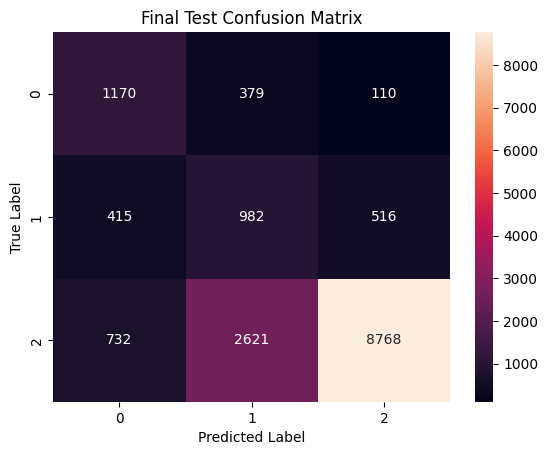

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Test Confusion Matrix')
plt.show()

**Hyperparameter Tuning & Optimization Summary**

| Tuning Stage | Parameter / Optimization Target | Best Configuration / Outcome |
| --- | --- | --- |
| **TF-IDF Vectorizer** | N-gram Range | `(1, 2)` (Unigrams + Bigrams) |
|  | Max Features | `5,000` |
|  | Sublinear Term Frequency | `True` (Logarithmic scaling) |
| **Logistic Regression** | Solver & Penalty | `liblinear` with `L2` regularization |
|  | Regularization Strength ($C$) | `1.0` |
|  | Base Class Weight | `'balanced'` |
| **Post-Processing** | Class Weight Multipliers | `[0.947, 1.063, 0.972]` |
| **Training Performance** | Train CV Macro F1 (Default) | **0.641** |
|  | Train CV Macro F1 (Tuned Multipliers) | **0.644** |
| **Validation Performance** | Validation Macro F1 (Default) | **0.587** |
|  | Validation Macro F1 (Tuned Multipliers) | **0.587** |
| **Final Strategy Selection** | Model Decision | **Adopt Tuned Multipliers** (Chosen based on cross-validation boost) |

### Model Comparison: Baseline vs. Tuned Model

| Metric | Dummy Classifier (Baseline) | Tuned Logistic Regression | Performance Lift ($\Delta$) |
| --- | --- | --- | --- |
| **Accuracy** | 0.106 | **0.696** | **+0.590** (+556.6%) |
| **Macro Precision** | 0.036 | **0.562** | **+0.526** (+1461.1%) |
| **Macro Recall** | 0.333 | **0.647** | **+0.314** (+94.3%) |
| **Macro F1-Score** | 0.063 | **0.579** | **+0.516** (+819.0%) |
| **Weighted F1-Score** | 0.020 | **0.732** | **+0.712** (+3560.0%) |

---

### Class-Wise F1-Score Comparison

| Class ID | Sentiment Class | Dummy Classifier F1 | Tuned Model F1 | Performance Lift ($\Delta$) |
| --- | --- | --- | --- | --- |
| **0** | Negative | 0.190 | **0.589** | **+0.399** |
| **1** | Neutral | 0.000 | **0.333** | **+0.333** |
| **2** | Positive | 0.000 | **0.815** | **+0.815** |

**Final Test Confusion Matrix Breakdown**

| True \ Predicted | Class 0 (Negative) | Class 1 (Neutral) | Class 2 (Positive) | Total Support |
| --- | --- | --- | --- | --- |
| **Class 0 (Negative)** | **1,170** *(TP)* | 379 | 110 | **1,659** |
| **Class 1 (Neutral)** | 415 | **982** *(TP)* | 516 | **1,913** |
| **Class 2 (Positive)** | 732 | 2,621 | **8,768** *(TP)* | **12,121** |
| **Total Predicted** | **2,317** | **3,982** | **9,394** | **15,693** |

---

**Key Findings & Error Analysis for Documentation**

* **High Positive Class Dominance (Class 2):** The model correctly identifies 8,768 positive reviews out of 12,121 (72.3% True Positive Rate/Recall), making it the most stable class.
* **Severe Misclassification into Class 1 (Neutral):** A total of **3,982 reviews** were predicted as Neutral, but only **982** were actually Neutral. The majority (2,621) were false positives coming from Class 2 (Positive), directly explaining why Neutral precision is low (24.7%).
* **Polar Class Separation (Class 0 vs Class 2):** Only 110 Negative reviews were wrongly predicted as Positive, and only 732 Positive reviews were predicted as Negative. The model distinguishes extreme positive from extreme negative sentiment well, but frequently gets confused by intermediate/neutral phrasing.

## Validation set results

In [ ]:
from sklearn.metrics import classification_report

pred_val_final = pred_val_tuned if USE_TUNED_WEIGHTS else pred_val_default

print(f"--- Val Performance used for the weighting decision "
      f"({'tuned multipliers' if USE_TUNED_WEIGHTS else 'default weights'}) ---")
print(f"Accuracy:  {accuracy_score(y_val, pred_val_final):.3f}")
print(f"F1 (macro):{f1_score(y_val, pred_val_final, average='macro', zero_division=0):.3f}\n")
print(classification_report(y_val, pred_val_final, zero_division=0, digits=3))

--- Val Performance used for the weighting decision (tuned multipliers) ---
Accuracy:  0.704
F1 (macro):0.587

              precision    recall  f1-score   support

           0      0.513     0.732     0.603      1647
           1      0.252     0.514     0.338      1894
           2      0.936     0.730     0.820     12144

    accuracy                          0.704     15685
   macro avg      0.567     0.659     0.587     15685
weighted avg      0.809     0.704     0.739     15685



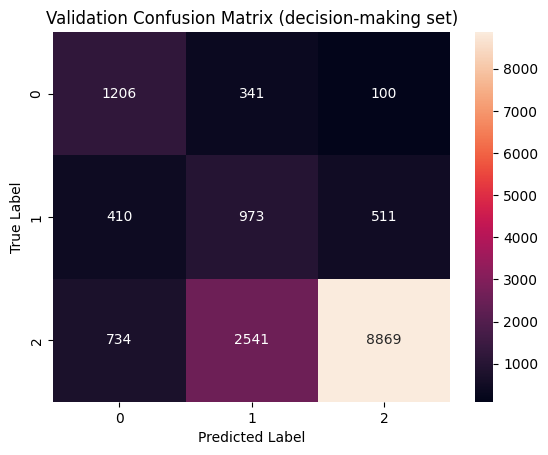

In [ ]:
cm_val = confusion_matrix(y_val, pred_val_final)
sns.heatmap(cm_val, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix (decision-making set)')
plt.show()

## Export finalized pipeline

In [ ]:
# from datetime import datetime, timezone
# import json
# import os
# import joblib
# from sklearn.metrics import accuracy_score, f1_score

# if exportModel:
#     # 1. Define and create export directory
#     model_dir = os.path.join(os.path.dirname(os.getcwd()), "LR_models")
#     os.makedirs(model_dir, exist_ok=True)

#     # 2. Serialize fitted Pipeline using joblib
#     pipeline_path = os.path.join(model_dir, "sentiment_pipeline_LR.pkl")
#     joblib.dump(best_pipeline, pipeline_path)

#     # 3. Handle non-serializable parameters (e.g., tuple for ngram_range)
#     clean_best_params = {
#         k: list(v) if isinstance(v, tuple) else v
#         for k, v in logistic_grid.best_params_.items()
#     }

#     # 4. Construct complete metadata payload
#     config = {
#         "best_params": clean_best_params,
#         "cv_best_score_f1_macro": float(logistic_grid.best_score_),  # Fixed key name
#         "use_tuned_weights": bool(USE_TUNED_WEIGHTS),
#         "class_weight_multipliers": best_weights.tolist() if hasattr(best_weights, 'tolist') else list(best_weights),
#         "val_f1_macro_default": float(f1_val_default),
#         "val_f1_macro_tuned": float(f1_val_tuned),
#         "test_accuracy": float(accuracy_score(y_test, pred_test)),
#         "test_f1_macro": float(f1_score(y_test, pred_test, average="macro", zero_division=0)),
#         "test_f1_weighted": float(f1_score(y_test, pred_test, average="weighted", zero_division=0)),
#         "exported_at_utc": datetime.now(timezone.utc).isoformat(),
#     }

#     # 5. Save metadata JSON
#     config_path = os.path.join(model_dir, "model_config.json")
#     with open(config_path, "w") as f:
#         json.dump(config, f, indent=2)

#     print(f"Pipeline successfully exported to: {pipeline_path}")
#     print(f"Model metadata exported to: {config_path}")
# else:
#     print("exportModel is set to False — skipping export.")

Pipeline successfully exported to: c:\Users\adham\OneDrive - Asia Pacific University\APU\DEGREE\LEVEL 3\SEM 1\sentiment analysis\assignment\Group Assignment Question-20260530\txsa part b\LR_models\sentiment_pipeline_LR.pkl
Model metadata exported to: c:\Users\adham\OneDrive - Asia Pacific University\APU\DEGREE\LEVEL 3\SEM 1\sentiment analysis\assignment\Group Assignment Question-20260530\txsa part b\LR_models\model_config.json


### testing using the model

In [ ]:
# import json
# import os
# import joblib
# import numpy as np

# # 1. Load exported pipeline and configuration file
# model_dir = os.path.join(os.path.dirname(os.getcwd()), "LR_models")

# pipeline_path = os.path.join(model_dir, "sentiment_pipeline_LR.pkl")
# config_path = os.path.join(model_dir, "model_config.json")

# # Load model pipeline
# loaded_pipeline = joblib.load(pipeline_path)

# # Load configuration metadata
# with open(config_path, "r") as f:
#     config = json.load(f)

# # Extract post-processing flags and multipliers
# use_tuned_weights = config.get("use_tuned_weights", False)
# multipliers = np.array(config.get("class_weight_multipliers", [1.0, 1.0, 1.0]))

# # 2. Define prediction function
# def predict_sentiment(text_list):
#     """Predicts sentiment classes (0=Negative, 1=Neutral, 2=Positive) for raw review texts.
    
#     Applies custom probability multipliers if configured in model metadata.
#     """
#     if use_tuned_weights:
#         # Get raw probability distributions for all 3 classes
#         raw_probs = loaded_pipeline.predict_proba(text_list)
#         # Apply the saved class multipliers
#         adjusted_probs = raw_probs * multipliers
#         # Pick class with highest adjusted probability score
#         predictions = np.argmax(adjusted_probs, axis=1)
#     else:
#         predictions = loaded_pipeline.predict(text_list)
        
#     return predictions

# # 3. Test with sample mixed-language reviews
# new_reviews = [
#     "Makanan sangat sedap, environment nice and cozy!",  # Expected: 2 (Positive)
#     "Servis biasa je, food was okay lah.",                # Expected: 1 (Neutral)
#     "Sangat mengecewakan, lambat and cold food.",        # Expected: 0 (Negative)
#     "the food was amazing, but the service was slow.",  # Expected: 1 (Neutral)
#     "I love the ambiance, great place to visit",  # Expected: 2 (Positive)
# ]

# # Run inference
# results = predict_sentiment(new_reviews)

# # Map numeric labels to human-readable tags
# label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# for text, label_id in zip(new_reviews, results):
#     print(f"Review: '{text}' --> Sentiment: {label_map[label_id]} (Class {label_id})")

Review: 'Makanan sangat sedap, environment nice and cozy!' --> Sentiment: Positive (Class 2)
Review: 'Servis biasa je, food was okay lah.' --> Sentiment: Neutral (Class 1)
Review: 'Sangat mengecewakan, lambat and cold food.' --> Sentiment: Negative (Class 0)
Review: 'the food was amazing, but the service was slow.' --> Sentiment: Negative (Class 0)
Review: 'I love the ambiance, great place to visit' --> Sentiment: Positive (Class 2)
